## 0. Imports and Configurations

In [ ]:
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import joblib
import s3fs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

load_dotenv()

USE_S3 = os.getenv("USE_S3", "false").lower() == "true"

## Load Cleaned Dataset

In [11]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, '..', 'data')

# Dynamic route to the data file
if USE_S3:
    df = pd.read_csv(f"s3://{os.getenv('S3_BUCKET')}/cleaned_data.csv")
else:
    df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)

BASE_DIR: /home/admin/Documents/nextbuy/notebooks
DATA_DIR: /home/admin/Documents/nextbuy/notebooks/../data


## Define target

In [12]:
basket_size = df.groupby('order_id').size().reset_index(name='basket_size')
print(basket_size.head())

   order_id  basket_size
0         2            9
1         4           13
2         6            3
3         8            1
4        21            5


## Orders dataset

In [13]:
orders = df.groupby('order_id').first().reset_index()

orders = orders.merge(basket_size, on='order_id')

## Feature engineering

In [14]:
# Features basées sur l'historique PASSÉ du user (pas de leakage)
orders = orders.sort_values(['user_id', 'order_number'])

# Taux de réachat par commande (sur df brut)
reorder_rate_per_order = (
    df.groupby('order_id')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate_this_order'})
)
orders = orders.merge(reorder_rate_per_order, on='order_id')

# Moyenne des tailles de panier des commandes précédentes
orders['user_avg_basket'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x: x.shift(1).expanding().mean())
)

orders['user_avg_basket3'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Variabilité
orders['user_std_basket'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x: x.shift(1).expanding().std())
)

# Taille du dernier panier
orders['user_last_basket'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x: x.shift(1))
)

# Taux de réachat historique moyen du user (commandes PASSÉES) safe
orders['user_reorder_rate'] = (
    orders.groupby('user_id')['reorder_rate_this_order']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Nombre de commandes passées
orders['user_n_orders_so_far'] = orders.groupby('user_id').cumcount()

# Supprimer les 1ères commandes (pas d'historique dispo)
orders = orders.dropna(subset=['user_avg_basket']).copy()

print(orders[['order_id', 'basket_size', 'user_avg_basket', 'user_reorder_rate', 'user_n_orders_so_far']].head(10))


    order_id  basket_size  user_avg_basket  user_reorder_rate  \
1     473747            5         6.000000           1.000000   
2    2398795            6         5.500000           0.800000   
3     431534            8         5.666667           0.700000   
4    2254736            5         6.250000           0.681250   
5    2550362            9         6.000000           0.745000   
8    2037211            5        11.000000           0.636364   
9     444309            9         8.000000           0.418182   
10    676467            6         8.333333           0.389899   
12   2030307            2         7.000000           0.142857   
13   2557754            3         4.500000           0.071429   

    user_n_orders_so_far  
1                      1  
2                      2  
3                      3  
4                      4  
5                      5  
8                      1  
9                      2  
10                     3  
12                     1  
13            

## Feature preparation

In [ ]:
features = [
    # variables temporelles
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    # historique client
    "order_number",
    # historique panier passé safe
    "user_avg_basket",       # moyenne des paniers précédents
    "user_avg_basket3",      # moyenne des 3 derniers paniers
    "user_std_basket",       # écart-type des paniers précédents
    "user_last_basket",      # taille du dernier panier
    "user_reorder_rate",     # taux de réachat historique du user
    "user_n_orders_so_far",  # nombre de commandes passées
]

target = "basket_size"

df_model = orders[features + [target]].dropna()
print(df_model.shape)


(921969, 11)


## Train test split

In [16]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Taille de l'ensemble d'entraînement :", X_train.shape)
print("Taille de l'ensemble de test :", X_test.shape)

Taille de l'ensemble d'entraînement : (737575, 10)
Taille de l'ensemble de test : (184394, 10)


## Baseline

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(rmse, mae, r2)

5.5986899096638 4.015555551650613 0.43986207363333496


## Random Forest

In [ ]:
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [10, 20, None],
    'model__min_samples_split': [2, 5],
}

# sample pour gridsearch
X_train_sample = X_train.sample(frac=0.2, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

grid_search = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_sample, y_train_sample)

print("Meilleurs paramètres :", grid_search.best_params_)

# reentrainer sur tout le train avec les meilleurs params
rf = grid_search.best_estimator_
rf.fit(X_train, y_train)
pred = rf.predict(X_test)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Meilleurs paramètres : {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Meilleurs paramètres : {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}


## Evaluation

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(rmse, mae, r2)

5.474919938347069 3.9126995019002586 0.4643542094610663


## Export

In [ ]:
if USE_S3:
    import s3fs
    fs = s3fs.S3FileSystem()
    with fs.open(f's3://{os.getenv('S3_BUCKET')}/model2.joblib', 'wb') as f:
        joblib.dump(rf, f)
    print(f'Model saved to: s3://{os.getenv('S3_BUCKET')}/model2.joblib')
else:
    models_dir = os.path.join(BASE_DIR, '..', 'models')
    os.makedirs(models_dir, exist_ok=True)
    out_path = os.path.join(models_dir, 'model2.joblib')
    joblib.dump(rf, out_path)
    print(f'Model saved to: {out_path}')

## Feature importance

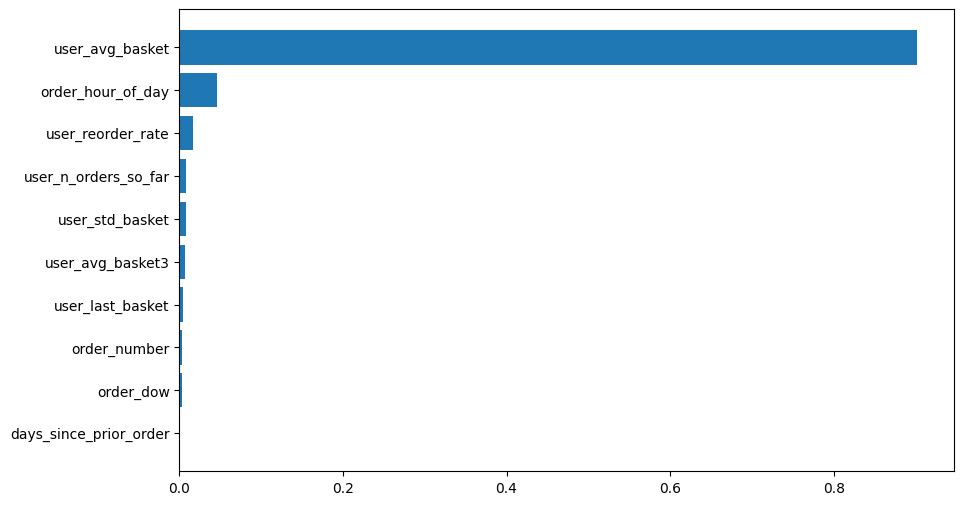

In [20]:
importances = rf.named_steps['model'].feature_importances_

indices = np.argsort(importances)
plt.figure(figsize=(10,6))
plt.barh(range(len(features)), importances[indices])
plt.yticks(range(len(features)), [features[i] for i in indices])
plt.show()